# Arquitetura Multilayer Perceptron (MLP)

Nesta seção, vamos visualizar a estrutura clássica de uma rede neural artificial: o Perceptron de Múltiplas Camadas (MLP - *Multilayer Perceptron*). 

A arquitetura que desenharemos a seguir é composta por:
1. **Camada de Entrada (Input Layer):** Representada por 3 nós (quadrados), recebe os dados de origem.
2. **Camada Oculta (Hidden Layer):** Representada por 5 nós (círculos), responsável por extrair padrões não lineares através das funções de ativação.
3. **Camada de Saída (Output Layer):** Representada por 2 nós (círculos), que consolidam as predições finais da rede (cenário comum para classificação binária com *one-hot encoding* ou regressão com múltiplas saídas).

Observe que se trata de uma rede densa (*Dense Layer* ou *Fully Connected*), onde cada nó de uma camada se conecta a todos os nós da camada subsequente através de sinapses (setas).

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# --- 1. CONFIGURAÇÕES DE IDENTIDADE VISUAL (PALETA GRAN) ---
COR_AZUL_PRINCIPAL = "#0D134C"
COR_VERMELHO = "#DD303E"
COR_PRETO = "#000000"
COR_BRANCO = "#FFFFFF"
FUNDO_EIXOS = "#F9F9F9"

# --- 2. CONFIGURAÇÕES DE TIPOGRAFIA (OTIMIZADO PARA PDF) ---
FONT_LABEL = 20
FONT_TICK = 18
FONT_SUBFIGURE = 24

# Garantindo suporte a glifos matemáticos e padronização da fonte
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

# Aplicação do estilo base
sns.set_theme(style="whitegrid", rc={
    "axes.facecolor": FUNDO_EIXOS,
    "figure.facecolor": FUNDO_EIXOS
})

# Fixando a semente
np.random.seed(28)

## Geração do Diagrama da Rede Neural

Abaixo, utilizaremos o Matplotlib para calcular as coordenadas topológicas da nossa rede neural e traçar as sinapses (conexões) e os neurônios (nós). 

Não utilizaremos dados externos em `.csv` para esta etapa, pois estamos construindo uma figura estritamente conceitual e arquitetural. Aplicaremos nossa paleta institucional para diferenciar visualmente cada tipo de camada, garantindo uma leitura limpa no PDF final.

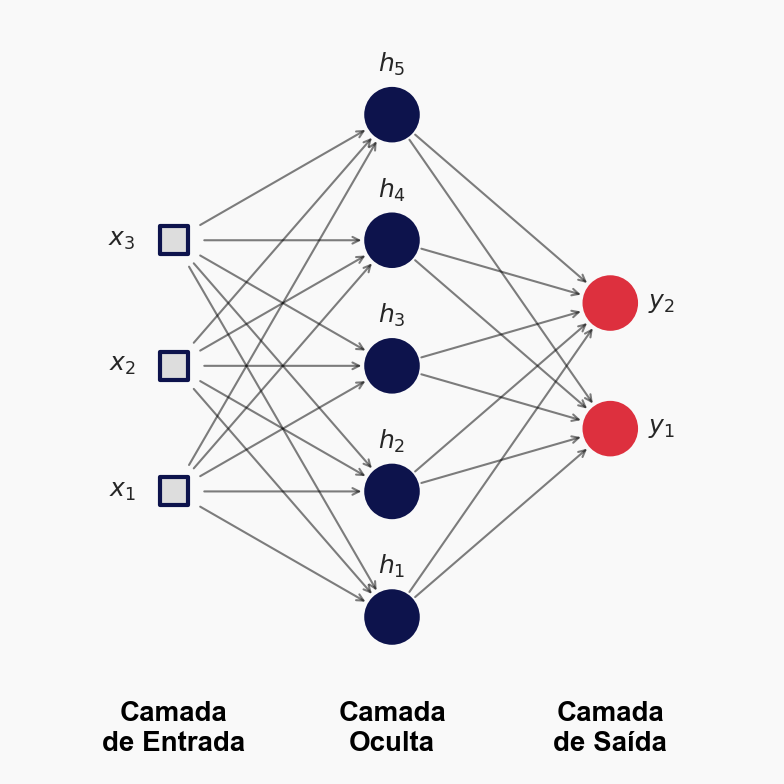

In [9]:
# --- 3. GERAÇÃO DA ARQUITETURA MLP (ATUALIZADA) ---
fig, ax = plt.subplots(figsize=(12, 8))

# Forçando o aspecto quadrado
ax.set_box_aspect(1)

# Removendo grades e bordas
ax.axis('off')
ax.grid(False)

# Estrutura da Rede Neural (Atualizado: 2 neurônios na saída)
tamanhos_camadas = [3, 5, 2]
espacamento_vertical = 1.2
espacamento_horizontal = 2.0

# Cálculo das coordenadas dos nós
coordenadas_nos = []
for i, tamanho in enumerate(tamanhos_camadas):
    coordenadas_camada = []
    y_offsets = np.linspace(-(tamanho - 1) * espacamento_vertical / 2, 
                            (tamanho - 1) * espacamento_vertical / 2, 
                            tamanho)
    for y in y_offsets:
        coordenadas_camada.append((i * espacamento_horizontal, y))
    coordenadas_nos.append(coordenadas_camada)

# Desenhando as conexões (sinapses) com SETAS PRETAS
for i in range(len(coordenadas_nos) - 1):
    for pt1 in coordenadas_nos[i]:
        for pt2 in coordenadas_nos[i+1]:
            # Setas pretas com opacidade ajustada para manter a legibilidade do diagrama
            ax.annotate("",
                        xy=pt2, xycoords='data',
                        xytext=pt1, textcoords='data',
                        arrowprops=dict(arrowstyle="->", color=COR_PRETO, alpha=0.5, 
                                        lw=1.5, shrinkA=22, shrinkB=22))

# Desenhando os nós com as especificações exigidas
# Camada 1: Entrada (Quadrados menores - s=800, preenchimento cinza, borda azul grossa)
x_in = [p[0] for p in coordenadas_nos[0]]
y_in = [p[1] for p in coordenadas_nos[0]]
ax.scatter(x_in, y_in, marker='s', s=400, facecolors='#DDDDDD', 
           edgecolors=COR_AZUL_PRINCIPAL, linewidths=3, zorder=3)

# Camada 2: Oculta (Círculos azuis, s=1600 - o dobro dos quadrados, sem borda preta)
x_hid = [p[0] for p in coordenadas_nos[1]]
y_hid = [p[1] for p in coordenadas_nos[1]]
ax.scatter(x_hid, y_hid, marker='o', s=1600, facecolors=COR_AZUL_PRINCIPAL, 
           edgecolors='none', zorder=3)

# Camada 3: Saída (Círculos vermelhos, s=1600)
x_out = [p[0] for p in coordenadas_nos[2]]
y_out = [p[1] for p in coordenadas_nos[2]]
ax.scatter(x_out, y_out, marker='o', s=1600, facecolors=COR_VERMELHO, 
           edgecolors='none', zorder=3)

# Adicionando a notação matemática
labels_notacao = [
    [fr'$x_{{{j+1}}}$' for j in range(tamanhos_camadas[0])], # Entrada
    [fr'$h_{{{j+1}}}$' for j in range(tamanhos_camadas[1])], # Oculta
    [fr'$y_{{{j+1}}}$' for j in range(tamanhos_camadas[2])]  # Saída
]

for i, coordenadas in enumerate(coordenadas_nos):
    for j, (x, y) in enumerate(coordenadas):
        # Offset para os labels não colarem nos marcadores
        if i == 0: 
            ax.text(x - 0.35, y, labels_notacao[i][j], fontsize=FONT_TICK, ha='right', va='center')
        elif i == 1: 
            ax.text(x, y + 0.35, labels_notacao[i][j], fontsize=FONT_TICK, ha='center', va='bottom')
        else: 
            ax.text(x + 0.35, y, labels_notacao[i][j], fontsize=FONT_TICK, ha='left', va='center')

# Nomes das camadas ancorados na base
nomes_camadas = ["Camada\nde Entrada", "Camada\nOculta", "Camada\nde Saída"]
for i, nome in enumerate(nomes_camadas):
    ax.text(i * espacamento_horizontal, -((max(tamanhos_camadas)-1) * espacamento_vertical / 2) - 0.8, 
            nome, fontsize=FONT_LABEL, ha='center', va='top', fontweight='bold', color=COR_PRETO)

# --- 4. AJUSTES FINAIS PARA EVITAR CORTES E EXPORTAÇÃO ---
ax.set_xlim(-1.5, (len(tamanhos_camadas) - 1) * espacamento_horizontal + 1.5)
ax.set_ylim(-((max(tamanhos_camadas)-1) * espacamento_vertical / 2) - 1.5, 
             ((max(tamanhos_camadas)-1) * espacamento_vertical / 2) + 1.0)

plt.tight_layout()

# Configuração do caminho de salvamento
caminho_save = os.path.join('..', 'outputs', 'figures', 'aula_06')
os.makedirs(caminho_save, exist_ok=True)

# Salvamento OBRIGATÓRIO (300 dpi, bbox_inches='tight', pad_inches=0.4)
plt.savefig(os.path.join(caminho_save, '01_arquitetura_mlp.png'), 
            dpi=300, 
            bbox_inches='tight', 
            pad_inches=0.4)

plt.show()